## Proyecto final


In [2]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt


I. Descripción del problema

El dengue es una enfermedad viral transmitida por el mosquito Aedes Aegypti y constituye uno de los problemas epidemiológicos más relevantes en Colombia. Su comportamiento no es uniforme: varía entre regiones, puede afectar más a ciertos grupos poblacionales, cambia por temporalidad, ciclos, clima y estacionalidad. Por este motivo, antes de modelar, se realizará un análisis descriptivo (EDA) para identificar qué grupos poblacionales y qué zonas del país presentan mayor incidencia, respondiendo preguntas como:

- ¿A quién afecta más el dengue: hombres o mujeres?

- ¿Existe un rango de edad más afectado?

- ¿Cuáles son los departamentos o zonas del país con mayor recurrencia?

- ¿Cómo se distribuye el dengue a lo largo del tiempo en los años 2022-2024?

Este análisis EDA permitirá justificar qué variables realmente aportan información útil para predicción.

Posteriormente, con base en el análisis exploratorio, se seleccionarán y transformarán las variables adecuadas para convertir el problema de ocurrencia del dengue en un problema de regresión supervisada en series temporales, utilizando como variable objetivo la cantidad de casos confirmados.

El objetivo principal de este trabajo es utilizar datos históricos reales de dengue correspondientes a los años 2022, 2023 y 2024, para entrenar modelos supervisados de Machine Learning que permitan proyectar cómo sería el comportamiento del dengue en Colombia en la siguiente ventana temporal futura.

Modelos utilizados

Para cumplir el objetivo, se implementarán y compararán los siguientes modelos supervisados:

- Regresión multivariada

- Árbol de decisión

- Random Forest

- Redes neuronales (MLP / DNN)

Cada modelo será evaluado utilizando técnicas de ajuste de hiperparámetros con GridSearchCV, y se compararán métricas de desempeño como MAE, MSE y R² para determinar cuál método ofrece la mejor capacidad predictiva para el comportamiento temporal del dengue nacional.

II. Inspección del Dataset inicial

El dataset original proviene de datos de vigilancia del sistema colombiano (años 2022-2024). Contiene múltiples columnas clínicas, administrativas, geográficas y epidemiológicas. Durante la inspección se identificó que muchas variables no son necesarias para el objetivo predicitivo planteado, por lo tanto, se realizará un proceso de limpieza y selección de variables.

In [3]:
df = pd.read_excel("Datos_22-24.xlsx", sheet_name="22-24", engine="openpyxl")

print("Filas y columnas:", df.shape)
df.head(10)

Filas y columnas: (501729, 73)


,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
0,8915475,210,2022-09-30,39,2022,8541000080,1,19,1,170,...,ESE HOSPITAL LOCAL DE TAURAMENA,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,TAURAMENA
1,8915476,210,2022-02-07,5,2022,8501000190,1,18,1,170,...,HOSPITAL DE AGUAZUL JUAN HERNANDO URREGO ESE,COLOMBIA,DENGUE,CASANARE,AGUAZUL,COLOMBIA,CASANARE,AGUAZUL,CASANARE,AGUAZUL
2,8915477,210,2022-04-08,13,2022,8500100001,3,19,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,YOPAL
3,8908033,210,2022-04-04,13,2022,8500100001,3,8,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL
4,8908034,210,2022-05-16,19,2022,5000600169,1,8,1,170,...,HOSPITAL MUNICIPAL DE ACACIAS,COLOMBIA,DENGUE,META,ACACIAS,COLOMBIA,META,ACACIAS,META,ACACIAS
5,8908035,210,2022-07-16,28,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
6,8908036,210,2022-05-15,19,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
7,8908037,210,2022-08-21,33,2022,5031300115,8,8,1,170,...,SERVIMEDICOS SAS,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
8,8908038,210,2022-11-03,43,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
9,8908039,210,2022-04-11,14,2022,8500100001,3,11,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL


III. Inspección y Análisis Exploratorio de Datos (EDA)

Para comprender el comportamiento del dengue en Colombia y caracterizar la población afectada, se realiza un análisis exploratorio de datos considerando aspectos demográficos y territoriales. El objetivo del EDA es identificar patrones y comportamientos relevantes para entender el fenómeno antes de aplicar los modelos supervisados.

Se analizan especialmente tres variables clave:

- SEXO: para evaluar si existe mayor afectación en hombres o mujeres.

- EDAD: para determinar qué rangos etarios presentan mayor frecuencia de casos.

- Departamento_ocurrencia: para identificar las zonas del país donde el dengue se presenta con mayor incidencia.

Este EDA permite contextualizar el fenómeno epidemiológico y da soporte a las decisiones posteriores de selección de características y construcción del modelo predictivo.


In [ ]:
df = pd.read_excel("Datos_22-24.xlsx", sheet_name="22-24", engine="openpyxl")

# Información general
print("Información general del dataset:")
df.info()
print("\nDescripción estadística general:")
display(df.describe(include='all'))


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501729 entries, 0 to 501728
Data columns (total 73 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   CONSECUTIVE                501729 non-null  int64         
 1   COD_EVE                    501729 non-null  int64         
 2   FEC_NOT                    501729 non-null  datetime64[ns]
 3   SEMANA                     501729 non-null  int64         
 4   ANO                        501729 non-null  int64         
 5   COD_PRE                    501729 non-null  int64         
 6   COD_SUB                    501729 non-null  int64         
 7   EDAD                       501729 non-null  int64         
 8   UNI_MED                    501729 non-null  int64         
 9   nacionalidad               501729 non-null  int64         
 10  nombre_nacionalidad        501729 non-null  object        
 11  SEXO               

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
count,5.017290e+05,501729.0,501729,501729.000000,501729.000000,5.017290e+05,501729.000000,501729.000000,501729.000000,501729.000000,...,498670,501729,501729,501729,501729,501729,501729,501727,501729,501729
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3571,45,1,33,970,49,34,1014,33,870
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,FUNDACION CLINICA INFANTIL CLUB NOEL,COLOMBIA,DENGUE,VALLE,CALI,COLOMBIA,VALLE,CALI,VALLE,CALI
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6628,500760,501729,116309,51550,500974,116013,52362,117121,58203
mean,1.074094e+07,210.0,2023-12-30 09:53:22.078413056,26.333979,2023.486191,5.166173e+09,4.860502,23.458742,1.015211,183.148546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.908033e+06,210.0,2022-01-02 00:00:00,1.000000,2022.000000,5.001000e+08,0.000000,1.000000,1.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.030206e+07,210.0,2023-08-12 00:00:00,15.000000,2023.000000,2.318201e+09,1.000000,10.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.096060e+07,210.0,2024-03-16 00:00:00,25.000000,2024.000000,6.600102e+09,1.000000,17.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.131224e+07,210.0,2024-07-02 00:00:00,38.000000,2024.000000,7.600103e+09,2.000000,32.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.174764e+07,210.0,2025-03-29 00:00:00,52.000000,2024.000000,9.977384e+09,99.000000,122.000000,4.000000,862.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


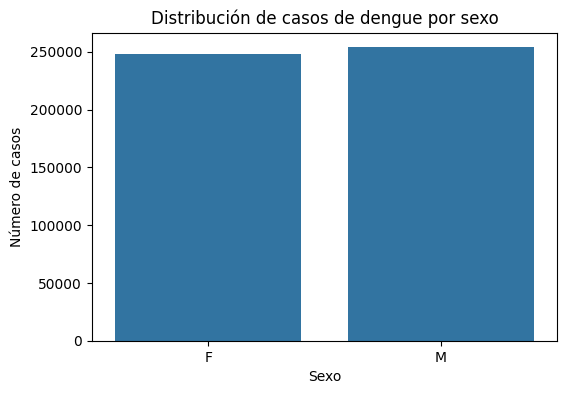

In [ ]:
# Distribución por sexo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SEXO")
plt.title("Distribución de casos de dengue por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

La distribución de casos de dengue por sexo muestra que la afectación entre hombres (M) y mujeres (F) es relativamente similar. No se evidencia una diferencia marcada de predominancia de un sexo sobre el otro, lo cual indica que la enfermedad no presenta una tendencia significativa por género en los registros analizados entre los años 2022 y 2024 en Colombia. Este patrón es consistente con literatura epidemiológica del dengue, donde el riesgo de infección está altamente correlacionado con exposición ambiental al vector y no con características biológicas específicas del sexo.

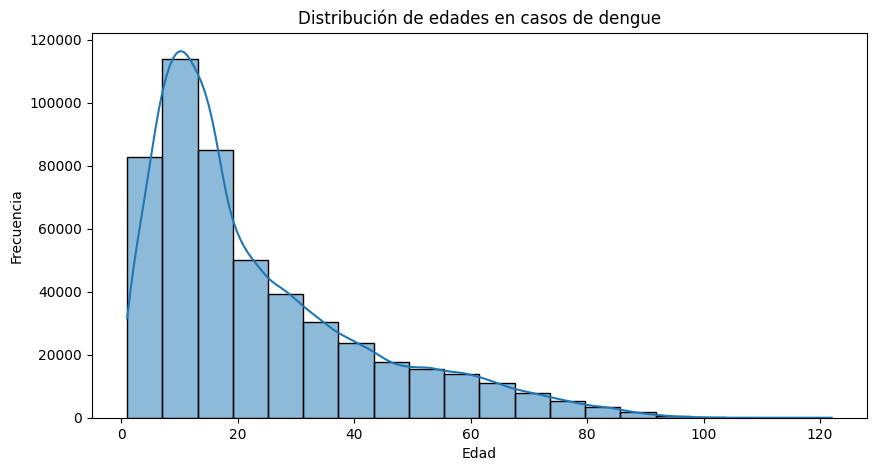

In [ ]:
# Distribución por edad
plt.figure(figsize=(10,5))
sns.histplot(df["EDAD"], bins=20, kde=True)
plt.title("Distribución de edades en casos de dengue")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edad de los casos reportados de dengue presenta una mayor concentración en población joven, especialmente entre aproximadamente 5 y 20 años. A medida que aumenta la edad, la frecuencia de casos disminuye progresivamente. Esto indica que la mayor carga de enfermedad se encuentra en población infantil, adolescente y adultos jóvenes, mientras que en población adulta mayor la incidencia es más baja. Este comportamiento es coherente con reportes epidemiológicos del dengue en Colombia, donde los menores tienen mayor exposición vectorial debido a contextos ambientales, escolares y comunitarios, especialmente en regiones endémicas.

Este patrón también indica que la edad, aunque es útil para caracterizar la población afectada, no necesariamente es una variable determinante para el modelo predictivo temporal nacional. Sin embargo, sí aporta evidencia de cómo se comporta el dengue en la población colombiana durante los años 2022-2024.

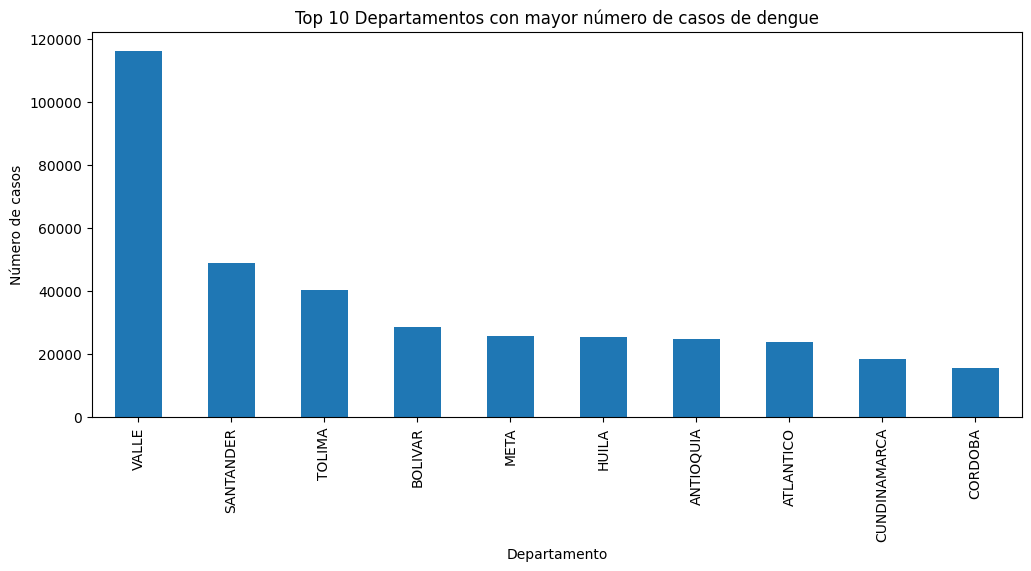

In [ ]:
# Top 10 Departamentos con más casos
plt.figure(figsize=(12,5))
df["Departamento_ocurrencia"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Departamentos con mayor número de casos de dengue")
plt.xlabel("Departamento")
plt.ylabel("Número de casos")
plt.show()

El análisis geográfico muestra que el mayor número de casos de dengue en Colombia se concentra principalmente en el departamento del Valle del Cauca, el cual presenta una carga significativamente superior respecto a los demás territorios. Posteriormente aparecen departamentos como Santander, Tolima, Bolívar, Meta, Huila, Antioquia, Atlántico, Cundinamarca y Córdoba.

Estos resultados indican que existe una alta concentración del dengue en regiones de clima cálido tropical y zonas con alta densidad poblacional, condiciones favorables para la reproducción del mosquito Aedes aegypti. Además, este patrón territorial sugiere que el dengue presenta una distribución geográfica heterogénea, siendo mucho más frecuente en ciertas zonas endémicas del país.

Este hallazgo respalda el concepto de que la ocurrencia del dengue no es homogénea a nivel nacional, sino que presenta focos de transmisión más intensa en departamentos específicos, lo cual debe tenerse en cuenta para interpretación epidemiológica del fenómeno.

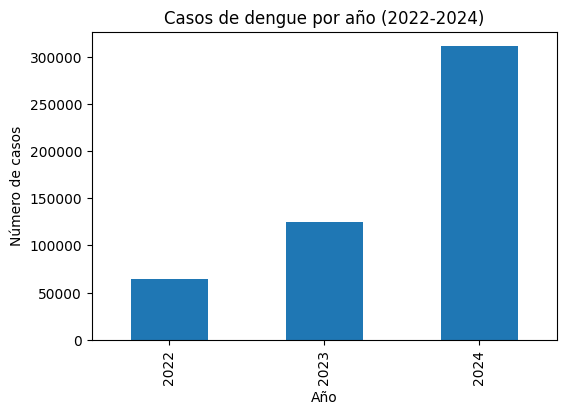

In [15]:
# Casos por año calendario
df["AÑO"] = pd.to_datetime(df["FEC_NOT"]).dt.year
df_filtrado = df[df["AÑO"].isin([2022, 2023, 2024])]
plt.figure(figsize=(6,4))
df_filtrado["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Casos de dengue por año (2022-2024)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.show()

El análisis de la serie de tiempo agregada de casos de dengue a nivel nacional (2022-2024) revela una marcada estacionalidad anual, evidenciada por picos recurrentes de casos en periodos específicos del año, lo cual es consistente con la influencia de variables climáticas en el ciclo de vida del vector. Adicionalmente, se observa una clara tendencia ascendente en la intensidad de estos picos, siendo el brote de 2024 el más significativo dentro del periodo analizado, señalando el desarrollo de un ciclo epidémico cada vez más fuerte. Este patrón combinado de Tendencia y Estacionalidad es la justificación principal para la selección de variables para el modelo predictivo, ya que el riesgo futuro a nivel país depende directamente de esta dinámica histórica. Por lo tanto, el objetivo es modelar este comportamiento temporal utilizando la fecha (FEC_NOT) y los casos confirmados, excluyendo las variables demográficas del modelo final, para predecir cuándo (en qué semanas o meses) se presentarán los mayores riesgos de incremento de dengue en el futuro.

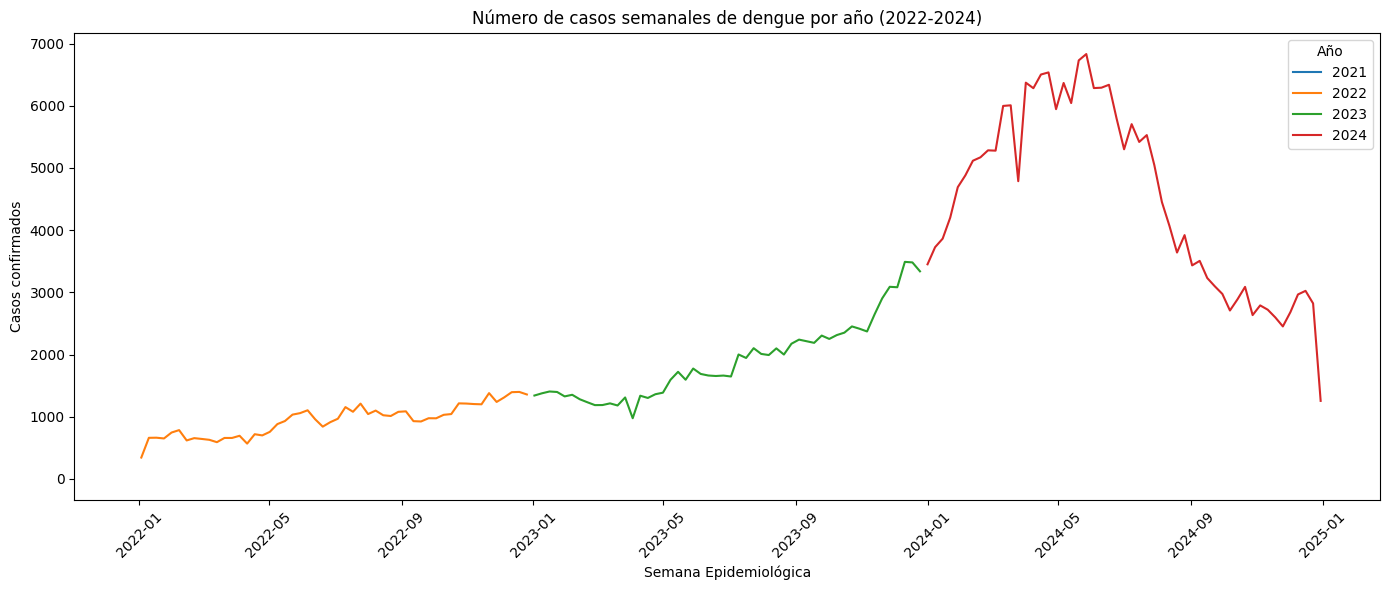

In [9]:


# Extraer año desde semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# Filtrar solo años reales del dataset (2022-2024)
serie_semanal = serie_semanal[serie_semanal['AÑO'] <= 2024]

# Gráfica de casos semanales por año
plt.figure(figsize=(14,6))

for year in serie_semanal['AÑO'].unique():
    subset = serie_semanal[serie_semanal['AÑO'] == year]
    plt.plot(subset['SEMANA'], subset['confirmados'], label=str(year))

plt.title("Número de casos semanales de dengue por año (2022-2024)")
plt.xlabel("Semana Epidemiológica")
plt.ylabel("Casos confirmados")
plt.legend(title="Año")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()






Estrategias utilizadas para preparar los datos

Durante la inspección inicial del conjunto de datos se identificó que el archivo original contenía una gran cantidad de variables relacionadas con clínica, ubicación geográfica, tipo de caso, entidad de aseguramiento, clasificación y variables textuales que no aportaban directamente al objetivo de predicción en este estudio. Debido a que este trabajo busca predecir el comportamiento futuro del dengue a nivel nacional, se decidió realizar una reducción de características, conservando únicamente las columnas relevantes para construir una serie temporal: la fecha de notificación (FEC_NOT) y el número de casos confirmados (confirmados).

Posteriormente se aplicaron las siguientes estrategias de preparación:

- Conversión de variables: la columna FEC_NOT fue convertida a tipo datetime para poder manipular adecuadamente la información temporal.

- Manejo de valores faltantes: se eliminaron registros que tenían fecha o número de casos faltantes. En la agregación semanal, valores faltantes resultantes se rellenaron con 0 para mantener la continuidad temporal.

- Agregación temporal: los registros individuales fueron transformados a un formato semanal sumando el número de casos confirmados por semana para obtener una serie temporal nacional.

- Reducción dimensional: se eliminaron todas las columnas restantes que no aportaban al objetivo del modelo, reduciendo así ruido y complejidad.

- Ingeniería de características: se generaron variables derivadas de series temporales (lag features y medias móviles) y variables estacionales (semana del año, mes, año) con el fin de transformar el problema de series temporales en un problema de regresión supervisada.

- Separación temporal de datos: la partición entre entrenamiento y prueba se realizó respetando el orden temporal de la serie (80% entrenamiento, 20% prueba), evitando introducir fuga de información.

- Estandarización: durante el entrenamiento, los modelos se ejecutan dentro de pipelines que realizan normalización de variables numéricas, lo cual es importante especialmente en redes neuronales y modelos como Random Forest.

Estas decisiones de preprocesamiento están directamente soportadas en la inspección y análisis del dataset, y permiten adaptar el conjunto de datos al tipo de tarea requerida por los modelos supervisados propuestos en este trabajo.

In [ ]:
# Selección de columnas relevantes
df = df[['FEC_NOT','confirmados']]

# Conversión de fecha
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# Eliminación filas con fecha o casos faltantes
df = df.dropna(subset=['FEC_NOT','confirmados'])

df.head()


IV. Construcción de la serie nacional semanal

Se agregan los casos confirmados semanalmente y se construyen variables de series temporales como lags y medias móviles, para convertir el problema de predicción de series de tiempo en un problema supervisado estándar.

In [ ]:
# crear semana
df['year_week'] = df['FEC_NOT'].dt.to_period('W').apply(lambda r: r.start_time)

series_weekly = df.groupby('year_week')['confirmados'].sum().sort_index()
series_weekly = series_weekly.asfreq('W-MON').fillna(0)
series_weekly = series_weekly.rename("cases")

def make_features(series, lags=[1,2,3,4], windows=[3,6]):
    df_feat = pd.DataFrame({'cases': series})
    
    # Crear variables de rezago (lags)
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['cases'].shift(lag)
    
    # Crear medias móviles
    for w in windows:
        df_feat[f'roll_mean_{w}'] = df_feat['cases'].shift(1).rolling(window=w, min_periods=1).mean()
    
    # Extraer características temporales usando isocalendar()
    df_feat['weekofyear'] = df_feat.index.isocalendar().week
    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    
    return df_feat.dropna()

V. Entrenamiento, ajuste de hiperparámetros y evaluación

Se entrenan los 4 modelos exigidos usando GridSearchCV y TimeSeriesSplit debido a que se trata de series temporales donde no se debe mezclar aleatoriamente el tiempo.

Métricas de evaluación:

- MAE

- MSE

- R²

In [ ]:
# Crear features para el modelo
df_feat = make_features(series_weekly)

# Verificar que se creó correctamente
print("Shape del DataFrame con features:", df_feat.shape)
print("\nPrimeras filas:")
print(df_feat.head())

# split temporal (no shuffle)
split_idx = int(len(df_feat)*0.8)
X = df_feat.drop(columns=['cases'])
y = df_feat['cases']
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

tscv = TimeSeriesSplit(n_splits=5)

# Modelos
models = {
    'linear': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'tree': Pipeline([('scaler', StandardScaler()), ('tree', DecisionTreeRegressor(random_state=42))]),
    'rf': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestRegressor(random_state=42))]),
    'mlp': Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(max_iter=1000, random_state=42))]),
}

# Grids
param_grids = {
    'linear': {'lr__fit_intercept':[True, False]},
    'tree': {'tree__max_depth':[3,5,10,None], 'tree__min_samples_split':[2,5,10]},
    'rf': {'rf__n_estimators':[50,100,200], 'rf__max_depth':[5,10,None]},
    'mlp': {'mlp__hidden_layer_sizes':[(50,),(100,),(100,50)], 'mlp__alpha':[0.0001,0.001]}
}

# Entrenamiento + evaluación
results = {}
for name, pipe in models.items():
    print("Entrenando:", name)
    grid = GridSearchCV(pipe, param_grids[name], cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'best_params': grid.best_params_, 'mae': mae, 'mse': mse, 'r2': r2, 'pred': y_pred}
    print(name, results[name])

# Dataframe comparativo
res_df = pd.DataFrame({k: {'MAE': v['mae'], 'MSE': v['mse'], 'R2': v['r2']} for k,v in results.items()}).T
res_df